# Day 5: Neo4j
## Graph-Enhanced Fraud Detection

Neo4j is the world's leading graph database. Where relational databases store data in tables and document databases store data as documents, Neo4j stores data as nodes and relationships. This makes it naturally suited to problems where the connections between entities are as important as the entities themselves.

**When would you reach for this?**
- Your data is highly connected and relationships carry meaning
- You need to traverse networks of entities to surface hidden patterns
- Vector similarity alone is insufficient - context and connections matter

**The use case:** A fraud detection system that combines vector similarity search with graph traversal. Pure vector search identifies transactions that look similar to known fraud. Graph traversal reveals the network of shared devices, IP addresses and merchants that links fraudulent accounts together. The combination surfaces fraud rings that neither approach could find alone.

## 1. Setup

### Prerequisites

- A Neo4j AuraDB account
- Ollama running locally with the `all-minilm` model pulled
- Python 3.12 with a virtual environment

### Create a Free Neo4j AuraDB Instance

If you do not already have an instance:

1. Go to [Neo4j Console](https://console.neo4j.io) and create an account
2. Click **Create free instance**
3. Download or copy the generated admin credentials

### Set Environment Variables

```bash
export NEO4J_URI="neo4j+s://xxxxxxxx.databases.neo4j.io"
export NEO4J_USERNAME="xxxxxxxx"
export NEO4J_PASSWORD="your-password"
export NEO4J_DATABASE="xxxxxxxx"
```

### Install Python Dependencies

In [1]:
%pip install ollama==0.6.2 \
             pandas==3.0.3 \
             neo4j==5.28.1 \
             networkx==3.4.2 \
             plotly==6.1.2 \
             tqdm==4.67.1 --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import networkx as nx
import ollama
import os
import plotly.graph_objects as go
import random
import pandas as pd
import time

from neo4j import GraphDatabase, NotificationDisabledCategory
from plotly.offline import init_notebook_mode
from tqdm.notebook import tqdm

### Configuration

In [3]:
NEO4J_URI        = os.environ["NEO4J_URI"]
NEO4J_USERNAME   = os.environ["NEO4J_USERNAME"]
NEO4J_PASSWORD   = os.environ["NEO4J_PASSWORD"]
NEO4J_DATABASE   = os.environ["NEO4J_DATABASE"]
LLM_EMBEDDING    = "all-minilm"
NUM_ACCOUNTS     = 50
NUM_TRANSACTIONS = 200
FRAUD_RATE       = 0.05
RANDOM_SEED      = 42

> **Note:** `NUM_ACCOUNTS` and `NUM_TRANSACTIONS` control the dataset size. The fraud rate is kept low to reflect real-world conditions - approximately 5% of transactions are fraudulent. Embedding generation runs locally via Ollama and is single-threaded. At 200 transactions the notebook runs comfortably. Larger values will work but will take proportionally longer.

### Verify Ollama is Running

In [4]:
ollama_ready = False

try:
    models = ollama.list()
    model_names = [m.model for m in models.models]
    assert any(LLM_EMBEDDING in m for m in model_names)
    print(f"Model '{LLM_EMBEDDING}' is ready.")
    ollama_ready = True
except ConnectionError:
    print("ERROR: Ollama is not running. Start it with: ollama serve")
except AssertionError:
    print(f"ERROR: Model not found. Run: ollama pull {LLM_EMBEDDING}")

Model 'all-minilm' is ready.


In [5]:
assert ollama_ready, "Please fix the Ollama issue above before continuing."

### Determine Embedding Dimensions

In [6]:
def get_embedding(text: str) -> list:
    response = ollama.embeddings(model = LLM_EMBEDDING, prompt = text)
    return response["embedding"]

test_embedding = get_embedding("suspicious transaction at an electronics merchant")
EMBEDDING_DIMS = len(test_embedding)
print(f"Embedding dimensions: {EMBEDDING_DIMS}")

Embedding dimensions: 384


### Connect to Neo4j AuraDB

In [7]:
driver = GraphDatabase.driver(
    NEO4J_URI,
    auth = (NEO4J_USERNAME, NEO4J_PASSWORD),
    notifications_disabled_categories = {NotificationDisabledCategory.DEPRECATION}
)

driver.verify_connectivity()

print("Connected to Neo4j AuraDB.")

Connected to Neo4j AuraDB.


## 2. The Dataset

We generate a synthetic fraud detection dataset with:

- **Accounts** - bank accounts with a name and account type
- **Transactions** - purchases with an amount, merchant category and a text description that we embed
- **Devices** - devices used to initiate transactions (shared devices are a fraud signal)
- **IP addresses** - network addresses used during transactions (shared IPs are a fraud signal)
- **Merchants** - fictional merchant names by category

A small number of accounts (~5%) are designated as fraudulent. Fraudulent accounts share devices and IP addresses with each other, forming a detectable fraud ring. Legitimate accounts do not share infrastructure with fraudulent ones.

Transaction descriptions are prose summaries that we embed - this is what the vector search operates on.

In [8]:
random.seed(RANDOM_SEED)

ACCOUNT_TYPES = ["checking", "savings", "business", "student"]

MERCHANT_CATEGORIES = [
    "electronics", "groceries", "travel", "dining", "clothing",
    "entertainment", "fuel", "pharmacy", "home improvement", "online retail",
]

FICTIONAL_MERCHANTS = {
    "electronics":      ["TechZone", "ByteShop", "CircuitWorld", "PixelMart"],
    "groceries":        ["FreshBasket", "GreenGrocer", "DailyMart", "HarvestHub"],
    "travel":           ["SkyHop", "RoamEasy", "JetPath", "WanderBookings"],
    "dining":           ["TastePlace", "QuickBite", "SavorStop", "MealSpot"],
    "clothing":         ["ThreadCo", "StyleVault", "WearHouse", "FabricFirst"],
    "entertainment":    ["PlayZone", "StreamHub", "FunPass", "EventLink"],
    "fuel":             ["QuickFuel", "RoadStop", "GasFast", "FuelPoint"],
    "pharmacy":         ["MediMart", "HealthPlus", "CareShop", "PharmaDirect"],
    "home improvement": ["BuildIt", "FixRight", "HomeBase", "ToolDen"],
    "online retail":    ["ShopNow", "DeliverDirect", "CartPlus", "BuyEasy"],
}

TRANSACTION_TEMPLATES = [
    "Purchase of ${amount} at {merchant}, a {category} merchant, using a {device_type} device.",
    "Transaction of ${amount} processed at {merchant} ({category}) from a {device_type}.",
    "{amount} dollar {category} purchase at {merchant} initiated from a {device_type} device.",
    "Payment of ${amount} to {merchant} for {category} goods via {device_type}.",
    "${amount} spent at {merchant}, categorized as {category}, from {device_type} device.",
]

FRAUD_TEMPLATES = [
    "Unusual purchase of ${amount} at {merchant} ({category}) from an unrecognized {device_type} device.",
    "High-value {category} transaction of ${amount} at {merchant} from a new {device_type} device.",
    "Suspicious ${amount} payment at {merchant} ({category}) initiated from an unfamiliar {device_type}.",
    "Out-of-pattern {category} purchase of ${amount} at {merchant} using an unverified {device_type} device.",
]

DEVICE_TYPES = ["mobile", "desktop", "tablet", "POS terminal"]

# Generate accounts
num_fraud_accounts = max(1, int(NUM_ACCOUNTS * FRAUD_RATE))
fraud_account_ids = set(random.sample(range(NUM_ACCOUNTS), num_fraud_accounts))

accounts = []
for i in range(NUM_ACCOUNTS):
    accounts.append({
        "account_id": f"ACC{i:04d}",
        "account_type": random.choice(ACCOUNT_TYPES),
        "is_fraud": i in fraud_account_ids,
    })

# Generate shared fraud infrastructure
fraud_devices = [f"DEV_FRAUD_{i:03d}" for i in range(3)]
fraud_ips = [f"192.168.{random.randint(10,99)}.{random.randint(1,254)}" for _ in range(3)]

# Generate legitimate devices and IPs
legit_devices = [f"DEV_LEGIT_{i:03d}" for i in range(NUM_ACCOUNTS * 2)]
legit_ips = [f"10.{random.randint(0,255)}.{random.randint(0,255)}.{random.randint(1,254)}" for _ in range(NUM_ACCOUNTS * 2)]

# Generate transactions
transactions = []
for i in range(NUM_TRANSACTIONS):
    account = random.choice(accounts)
    category = random.choice(MERCHANT_CATEGORIES)
    merchant = random.choice(FICTIONAL_MERCHANTS[category])
    device_type = random.choice(DEVICE_TYPES)
    is_fraud_txn = account["is_fraud"] and random.random() < 0.7

    if is_fraud_txn:
        amount = round(random.uniform(500, 5000), 2)
        template = random.choice(FRAUD_TEMPLATES)
        device = random.choice(fraud_devices)
        ip = random.choice(fraud_ips)
    else:
        amount = round(random.uniform(5, 500), 2)
        template = random.choice(TRANSACTION_TEMPLATES)
        device = random.choice(legit_devices)
        ip = random.choice(legit_ips)

    description = template.format(
        amount = f"{amount:.2f}",
        merchant = merchant,
        category = category,
        device_type = device_type,
    )

    transactions.append({
        "transaction_id": f"TXN{i:05d}",
        "account_id": account["account_id"],
        "amount": amount,
        "category": category,
        "merchant": merchant,
        "device_id": device,
        "ip_address": ip,
        "is_fraud": is_fraud_txn,
        "description": description,
    })

df = pd.DataFrame(transactions)

print(f"Generated {len(accounts)} accounts ({num_fraud_accounts} fraudulent)")
print(f"Generated {len(transactions)} transactions ({df['is_fraud'].sum()} fraudulent)")
df.head()

Generated 50 accounts (2 fraudulent)
Generated 200 transactions (3 fraudulent)


,transaction_id,account_id,amount,category,merchant,device_id,ip_address,is_fraud,description
0,TXN00000,ACC0023,342.62,electronics,CircuitWorld,DEV_LEGIT_045,10.65.21.79,False,"Purchase of $342.62 at CircuitWorld, a electro..."
1,TXN00001,ACC0035,432.98,fuel,RoadStop,DEV_LEGIT_052,10.236.194.70,False,Transaction of $432.98 processed at RoadStop (...
2,TXN00002,ACC0011,137.07,entertainment,EventLink,DEV_LEGIT_048,10.112.166.216,False,"Purchase of $137.07 at EventLink, a entertainm..."
3,TXN00003,ACC0030,178.08,dining,QuickBite,DEV_LEGIT_028,10.236.194.70,False,Transaction of $178.08 processed at QuickBite ...
4,TXN00004,ACC0042,142.91,dining,MealSpot,DEV_LEGIT_098,10.102.159.103,False,"Purchase of $142.91 at MealSpot, a dining merc..."


## 3. Clear the Database

We clear the database before each run to ensure a clean start. On AuraDB Free the database name is auto-generated and matches the instance ID.

In [9]:
with driver.session(database = NEO4J_DATABASE) as session:
    session.run("MATCH (n) DETACH DELETE n")
    print("Database cleared.")

Database cleared.


## 4. Load the Graph

We create the graph structure in Neo4j:

- **Account** nodes - one per account
- **Transaction** nodes - one per transaction, with the embedding stored as a property
- **Device** nodes - one per unique device ID
- **IpAddress** nodes - one per unique IP address
- **Merchant** nodes - one per unique merchant name

Relationships:
- `(:Account)-[:MADE]->(:Transaction)`
- `(:Transaction)-[:USED_DEVICE]->(:Device)`
- `(:Transaction)-[:FROM_IP]->(:IpAddress)`
- `(:Transaction)-[:AT_MERCHANT]->(:Merchant)`

In [10]:
# Create constraints for uniqueness
with driver.session(database = NEO4J_DATABASE) as session:
    session.run("CREATE CONSTRAINT IF NOT EXISTS FOR (a:Account) REQUIRE a.account_id IS UNIQUE")
    session.run("CREATE CONSTRAINT IF NOT EXISTS FOR (t:Transaction) REQUIRE t.transaction_id IS UNIQUE")
    session.run("CREATE CONSTRAINT IF NOT EXISTS FOR (d:Device) REQUIRE d.device_id IS UNIQUE")
    session.run("CREATE CONSTRAINT IF NOT EXISTS FOR (i:IpAddress) REQUIRE i.ip_address IS UNIQUE")
    session.run("CREATE CONSTRAINT IF NOT EXISTS FOR (m:Merchant) REQUIRE m.name IS UNIQUE")
    print("Constraints created.")

Constraints created.


In [11]:
# Load accounts
with driver.session(database = NEO4J_DATABASE) as session:
    for account in accounts:
        session.run("""
            MERGE (a:Account {account_id: $account_id})
            SET a.account_type = $account_type,
                a.is_fraud = $is_fraud
        """, **account)

print(f"Loaded {len(accounts)} accounts.")

Loaded 50 accounts.


In [12]:
# Load transactions with embeddings
with driver.session(database = NEO4J_DATABASE) as session:
    for txn in tqdm(transactions, desc = "Loading transactions"):
        embedding = get_embedding(txn["description"])
        session.run("""
            MATCH (a:Account {account_id: $account_id})
            MERGE (t:Transaction {transaction_id: $transaction_id})
            SET t.amount = $amount,
                t.category = $category,
                t.merchant = $merchant,
                t.is_fraud = $is_fraud,
                t.description = $description,
                t.embedding = $embedding
            MERGE (a)-[:MADE]->(t)
            MERGE (d:Device {device_id: $device_id})
            MERGE (t)-[:USED_DEVICE]->(d)
            MERGE (i:IpAddress {ip_address: $ip_address})
            MERGE (t)-[:FROM_IP]->(i)
            MERGE (m:Merchant {name: $merchant})
            MERGE (t)-[:AT_MERCHANT]->(m)
        """,
            transaction_id = txn["transaction_id"],
            account_id = txn["account_id"],
            amount = txn["amount"],
            category = txn["category"],
            merchant = txn["merchant"],
            device_id = txn["device_id"],
            ip_address = txn["ip_address"],
            is_fraud = txn["is_fraud"],
            description = txn["description"],
            embedding = embedding
        )

print(f"\nLoaded {len(transactions)} transactions with embeddings.")

Loading transactions:   0%|          | 0/200 [00:00<?, ?it/s]


Loaded 200 transactions with embeddings.


## 5. Create the Vector Index

Neo4j supports native vector indexes via Cypher. We create an index on the `embedding` property of `Transaction` nodes using the `EMBEDDING_DIMS` variable to keep the index definition in sync with the embedding model.

In [13]:
with driver.session(database = NEO4J_DATABASE) as session:
    session.run("DROP INDEX transaction_embeddings IF EXISTS")
    session.run(f"""
        CREATE VECTOR INDEX transaction_embeddings
        FOR (t:Transaction) ON (t.embedding)
        OPTIONS {{indexConfig: {{
            `vector.dimensions`: {EMBEDDING_DIMS},
            `vector.similarity_function`: 'cosine'
        }}}}
    """)

    print(f"Vector index created with {EMBEDDING_DIMS} dimensions.")

Vector index created with 384 dimensions.


### Wait for the Vector Index to be Online

In [14]:
print("Waiting for vector index to be online...")

while True:
    with driver.session(database = NEO4J_DATABASE) as session:
        result = session.run("""
            SHOW INDEXES
            WHERE name = 'transaction_embeddings'
        """)
        record = result.single()
        state  = record["state"] if record else "NOT FOUND"
        if state == "ONLINE":
            print(f"Vector index is online.")
            break
        print(f"  State: {state} - waiting...")
        time.sleep(3)

Waiting for vector index to be online...
Vector index is online.


## 6. Vector Search - Find Similar Transactions

We start with pure vector search to find transactions similar to a known fraudulent pattern. This is the baseline - it finds semantically similar transactions but has no awareness of the graph structure.

In [15]:
def vector_search(query: str, top_k: int = 5):
    query_embedding = get_embedding(query)

    with driver.session(database = NEO4J_DATABASE) as session:
        result = session.run("""
            CALL db.index.vector.queryNodes(
                'transaction_embeddings', $top_k, $embedding
            ) YIELD node AS t, score
            MATCH (a:Account)-[:MADE]->(t)
            RETURN t.transaction_id AS transaction_id,
                   a.account_id AS account_id,
                   t.amount AS amount,
                   t.category AS category,
                   t.merchant AS merchant,
                   t.is_fraud AS is_fraud,
                   t.description AS description,
                   score
            ORDER BY score DESC
        """, embedding = query_embedding, top_k = top_k)

        records = result.data()

    print(f"\nVector search: '{query}'\n")
    for r in records:
        fraud_label = "[FRAUD]" if r["is_fraud"] else "[OK]"
        print(f"  {r['transaction_id']} | {r['account_id']} | ${r['amount']:.2f} | {r['category']} | {fraud_label}")
        print(f"  Score: {r['score']:.3f} | {r['description']}")
        print()

In [16]:
vector_search("suspicious high-value purchase at an electronics merchant from an unrecognized device")


Vector search: 'suspicious high-value purchase at an electronics merchant from an unrecognized device'

  TXN00156 | ACC0028 | $339.80 | electronics | [OK]
  Score: 0.780 | Transaction of $339.80 processed at PixelMart (electronics) from a tablet.

  TXN00115 | ACC0032 | $397.58 | online retail | [OK]
  Score: 0.779 | Purchase of $397.58 at BuyEasy, a online retail merchant, using a mobile device.

  TXN00056 | ACC0019 | $474.06 | online retail | [OK]
  Score: 0.776 | Transaction of $474.06 processed at ShopNow (online retail) from a mobile.

  TXN00087 | ACC0042 | $340.42 | electronics | [OK]
  Score: 0.775 | Transaction of $340.42 processed at PixelMart (electronics) from a tablet.

  TXN00107 | ACC0009 | $429.91 | online retail | [OK]
  Score: 0.772 | Transaction of $429.91 processed at ShopNow (online retail) from a tablet.



In [17]:
vector_search("unusual out-of-pattern transaction from unfamiliar device")


Vector search: 'unusual out-of-pattern transaction from unfamiliar device'

  TXN00156 | ACC0028 | $339.80 | electronics | [OK]
  Score: 0.739 | Transaction of $339.80 processed at PixelMart (electronics) from a tablet.

  TXN00056 | ACC0019 | $474.06 | online retail | [OK]
  Score: 0.737 | Transaction of $474.06 processed at ShopNow (online retail) from a mobile.

  TXN00161 | ACC0032 | $473.47 | travel | [OK]
  Score: 0.736 | Transaction of $473.47 processed at WanderBookings (travel) from a mobile.

  TXN00087 | ACC0042 | $340.42 | electronics | [OK]
  Score: 0.733 | Transaction of $340.42 processed at PixelMart (electronics) from a tablet.

  TXN00125 | ACC0019 | $94.80 | entertainment | [OK]
  Score: 0.731 | Transaction of $94.80 processed at FunPass (entertainment) from a mobile.



## 7. Graph Traversal - Find Connected Accounts

Graph traversal reveals the network behind fraud. Here we find all accounts that share a device or IP address with a known fraudulent account. These shared infrastructure patterns are a strong signal of coordinated fraud rings.

This query is pure Cypher - no vector search involved. It traverses the graph two hops from a flagged account: `account -> transaction -> device/IP -> transaction -> account`.

In [18]:
def find_connected_accounts(account_id: str):
    with driver.session(database = NEO4J_DATABASE) as session:
        result = session.run("""
            MATCH (a:Account {account_id: $account_id})-[:MADE]->(t:Transaction)
            MATCH (t)-[:USED_DEVICE|FROM_IP]->(shared)<-[:USED_DEVICE|FROM_IP]-(t2:Transaction)
            MATCH (a2:Account)-[:MADE]->(t2)
            WHERE a2.account_id <> $account_id
            RETURN DISTINCT
                a2.account_id AS connected_account,
                a2.account_type AS account_type,
                a2.is_fraud AS is_fraud,
                labels(shared)[0] AS shared_via,
                CASE labels(shared)[0]
                    WHEN 'Device' THEN shared.device_id
                    WHEN 'IpAddress' THEN shared.ip_address
                END AS shared_value
            ORDER BY a2.is_fraud DESC
        """, account_id = account_id)

        records = result.data()

    print(f"\nAccounts connected to {account_id} via shared devices or IP addresses:\n")
    if not records:
        print("  No connected accounts found.")
        return
    for r in records:
        fraud_label = "[FRAUD]" if r["is_fraud"] else "[OK]"
        print(f"  {r['connected_account']} ({r['account_type']}) {fraud_label}")
        print(f"  Shared via {r['shared_via']}: {r['shared_value']}")
        print()

# Find a known fraudulent account to investigate
fraud_accounts = [a["account_id"] for a in accounts if a["is_fraud"]]

print(f"Known fraudulent accounts: {fraud_accounts}")
find_connected_accounts(fraud_accounts[0])

Known fraudulent accounts: ['ACC0007', 'ACC0040']

Accounts connected to ACC0007 via shared devices or IP addresses:

  ACC0040 (business) [FRAUD]
  Shared via Device: DEV_FRAUD_002

  ACC0006 (checking) [OK]
  Shared via Device: DEV_LEGIT_071

  ACC0049 (student) [OK]
  Shared via Device: DEV_LEGIT_071

  ACC0049 (student) [OK]
  Shared via IpAddress: 10.242.208.49

  ACC0024 (savings) [OK]
  Shared via IpAddress: 10.242.208.49

  ACC0015 (student) [OK]
  Shared via IpAddress: 10.242.208.49



## 8. Combined Graph + Vector Search

This is where the graph advantage is clearest. We combine vector similarity search with graph traversal in a single Cypher query:

1. Find transactions semantically similar to a known fraud pattern (vector search)
2. For each similar transaction, traverse the graph to find all accounts sharing devices or IP addresses
3. Return the full network of potentially connected fraudulent activity

This surfaces fraud rings that pure vector search cannot see - accounts that look normal in isolation but are connected through shared infrastructure to flagged transactions.

In [19]:
def graph_vector_search(query: str, top_k: int = 5, similarity_threshold: float = 0.7):
    query_embedding = get_embedding(query)

    with driver.session(database = NEO4J_DATABASE) as session:
        result = session.run("""
            // Step 1: find similar transactions via vector search
            CALL db.index.vector.queryNodes(
                'transaction_embeddings', $top_k, $embedding
            ) YIELD node AS t, score
            WHERE score >= $threshold

            // Step 2: traverse the graph to find connected accounts
            MATCH (a:Account)-[:MADE]->(t)
            MATCH (t)-[:USED_DEVICE|FROM_IP]->(shared)<-[:USED_DEVICE|FROM_IP]-(t2:Transaction)
            MATCH (a2:Account)-[:MADE]->(t2)

            // Step 3: return the network
            RETURN DISTINCT
                t.transaction_id AS similar_transaction,
                score AS similarity,
                a.account_id AS flagged_account,
                a.is_fraud AS flagged_is_fraud,
                a2.account_id AS connected_account,
                a2.is_fraud AS connected_is_fraud,
                labels(shared)[0] AS shared_via
            ORDER BY score DESC, a2.is_fraud DESC
        """,
            embedding = query_embedding,
            top_k = top_k,
            threshold = similarity_threshold
        )

        records = result.data()

    print(f"\nGraph + vector search: '{query}'\n")
    if not records:
        print("  No results above similarity threshold.")
        return
    for r in records:
        flagged_label = "[FRAUD]" if r["flagged_is_fraud"]   else "[OK]"
        connected_label = "[FRAUD]" if r["connected_is_fraud"] else "[OK]"
        print(f"  Similar transaction: {r['similar_transaction']} | Score: {r['similarity']:.3f}")
        print(f"  Flagged account:     {r['flagged_account']} {flagged_label}")
        print(f"  Connected account:   {r['connected_account']} {connected_label} (via {r['shared_via']})")
        print()

In [20]:
graph_vector_search(
    "suspicious high-value purchase from an unrecognized device",
    top_k = 10,
    similarity_threshold = 0.7
)


Graph + vector search: 'suspicious high-value purchase from an unrecognized device'

  Similar transaction: TXN00087 | Score: 0.771
  Flagged account:     ACC0042 [OK]
  Connected account:   ACC0040 [FRAUD] (via IpAddress)

  Similar transaction: TXN00087 | Score: 0.771
  Flagged account:     ACC0042 [OK]
  Connected account:   ACC0027 [OK] (via Device)

  Similar transaction: TXN00087 | Score: 0.771
  Flagged account:     ACC0042 [OK]
  Connected account:   ACC0005 [OK] (via Device)

  Similar transaction: TXN00087 | Score: 0.771
  Flagged account:     ACC0042 [OK]
  Connected account:   ACC0046 [OK] (via Device)

  Similar transaction: TXN00087 | Score: 0.771
  Flagged account:     ACC0042 [OK]
  Connected account:   ACC0014 [OK] (via IpAddress)

  Similar transaction: TXN00156 | Score: 0.771
  Flagged account:     ACC0028 [OK]
  Connected account:   ACC0036 [OK] (via Device)

  Similar transaction: TXN00156 | Score: 0.771
  Flagged account:     ACC0028 [OK]
  Connected account:   A

In [21]:
graph_vector_search(
    "unusual out-of-pattern transaction from unfamiliar device",
    top_k = 10,
    similarity_threshold = 0.65
)


Graph + vector search: 'unusual out-of-pattern transaction from unfamiliar device'

  Similar transaction: TXN00156 | Score: 0.739
  Flagged account:     ACC0028 [OK]
  Connected account:   ACC0036 [OK] (via Device)

  Similar transaction: TXN00156 | Score: 0.739
  Flagged account:     ACC0028 [OK]
  Connected account:   ACC0015 [OK] (via IpAddress)

  Similar transaction: TXN00156 | Score: 0.739
  Flagged account:     ACC0028 [OK]
  Connected account:   ACC0002 [OK] (via IpAddress)

  Similar transaction: TXN00156 | Score: 0.739
  Flagged account:     ACC0028 [OK]
  Connected account:   ACC0031 [OK] (via IpAddress)

  Similar transaction: TXN00161 | Score: 0.736
  Flagged account:     ACC0032 [OK]
  Connected account:   ACC0002 [OK] (via Device)

  Similar transaction: TXN00161 | Score: 0.736
  Flagged account:     ACC0032 [OK]
  Connected account:   ACC0019 [OK] (via Device)

  Similar transaction: TXN00161 | Score: 0.736
  Flagged account:     ACC0032 [OK]
  Connected account:   AC

## 9. Fraud Ring Summary

A final query summarizes the fraud ring structure - which devices and IP addresses are shared between multiple accounts, and how many of those accounts are flagged as fraudulent.

In [22]:
with driver.session(database = NEO4J_DATABASE) as session:
    result = session.run("""
        MATCH (a:Account)-[:MADE]->(t:Transaction)-[:USED_DEVICE]->(d:Device)
        WITH d, collect(DISTINCT a) AS accounts
        WHERE size(accounts) > 1
        RETURN d.device_id AS device_id,
               size(accounts) AS num_accounts,
               size([a IN accounts WHERE a.is_fraud = true]) AS fraud_accounts
        ORDER BY fraud_accounts DESC, num_accounts DESC
    """)
    records = result.data()

print("Devices shared between multiple accounts:\n")
for r in records:
    print(f"  Device: {r['device_id']}")
    print(f"  Accounts: {r['num_accounts']} total, {r['fraud_accounts']} fraudulent")
    print()

Devices shared between multiple accounts:

  Device: DEV_FRAUD_002
  Accounts: 2 total, 2 fraudulent

  Device: DEV_LEGIT_071
  Accounts: 3 total, 1 fraudulent

  Device: DEV_LEGIT_086
  Accounts: 3 total, 1 fraudulent

  Device: DEV_LEGIT_038
  Accounts: 6 total, 0 fraudulent

  Device: DEV_LEGIT_067
  Accounts: 5 total, 0 fraudulent

  Device: DEV_LEGIT_016
  Accounts: 5 total, 0 fraudulent

  Device: DEV_LEGIT_089
  Accounts: 5 total, 0 fraudulent

  Device: DEV_LEGIT_042
  Accounts: 5 total, 0 fraudulent

  Device: DEV_LEGIT_055
  Accounts: 5 total, 0 fraudulent

  Device: DEV_LEGIT_041
  Accounts: 4 total, 0 fraudulent

  Device: DEV_LEGIT_057
  Accounts: 4 total, 0 fraudulent

  Device: DEV_LEGIT_083
  Accounts: 4 total, 0 fraudulent

  Device: DEV_LEGIT_009
  Accounts: 4 total, 0 fraudulent

  Device: DEV_LEGIT_034
  Accounts: 4 total, 0 fraudulent

  Device: DEV_LEGIT_036
  Accounts: 4 total, 0 fraudulent

  Device: DEV_LEGIT_084
  Accounts: 4 total, 0 fraudulent

  Device: DEV

## 10. Fraud Ring Network Plot

In [23]:
init_notebook_mode(connected = True)

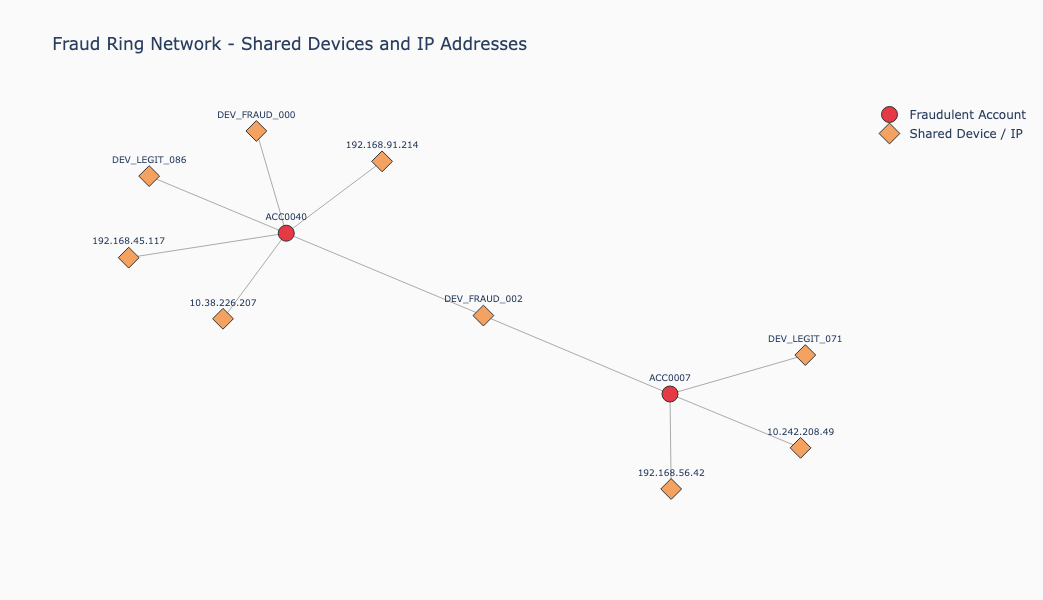

In [24]:
# Fraud ring network visualization
# Fetch the fraud ring subgraph from Neo4j

with driver.session(database = NEO4J_DATABASE) as session:
    result = session.run("""
        MATCH (a:Account)-[:MADE]->(t:Transaction)-[:USED_DEVICE]->(d:Device)
        WHERE a.is_fraud = true OR d.device_id STARTS WITH 'DEV_FRAUD'
        RETURN a.account_id AS account,
               a.is_fraud AS account_fraud,
               d.device_id AS device
        UNION
        MATCH (a:Account)-[:MADE]->(t:Transaction)-[:FROM_IP]->(i:IpAddress)
        WHERE a.is_fraud = true
        RETURN a.account_id AS account,
               a.is_fraud AS account_fraud,
               i.ip_address AS device
    """)
    ring_records = result.data()

# Build networkx graph
G = nx.Graph()

for r in ring_records:
    acc = r["account"]
    shared = r["device"]
    is_fraud = r["account_fraud"]

    G.add_node(acc, node_type = "account", is_fraud = is_fraud)
    G.add_node(shared, node_type = "shared")
    G.add_edge(acc, shared)

# Compute layout
pos = nx.spring_layout(G, seed = RANDOM_SEED)

# Build edge traces
edge_x, edge_y = [], []
for u, v in G.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x = edge_x, y = edge_y,
    mode = "lines",
    line = dict(width = 1, color = "#AAAAAA"),
    hoverinfo = "none",
    showlegend = False
)

# Build node traces by type
def make_node_trace(nodes, color, symbol, name):
    x = [pos[n][0] for n in nodes]
    y = [pos[n][1] for n in nodes]
    return go.Scatter(
        x = x, y = y,
        mode = "markers+text",
        marker = dict(size = 16, color = color, symbol = symbol, line = dict(width = 1, color = "#333")),
        text = nodes,
        textposition = "top center",
        textfont = dict(size = 9),
        name = name,
        hovertext = nodes,
        hoverinfo = "text"
    )

fraud_accounts = [n for n, d in G.nodes(data = True) if d.get("node_type") == "account" and d.get("is_fraud")]
legit_accounts = [n for n, d in G.nodes(data = True) if d.get("node_type") == "account" and not d.get("is_fraud")]
shared_nodes   = [n for n, d in G.nodes(data = True) if d.get("node_type") == "shared"]

fig = go.Figure(
    data = [
        edge_trace,
        make_node_trace(fraud_accounts, "#E63946", "circle",  "Fraudulent Account"),
        make_node_trace(legit_accounts, "#457B9D", "circle",  "Legitimate Account"),
        make_node_trace(shared_nodes,   "#F4A261", "diamond", "Shared Device / IP"),
    ],
    layout = go.Layout(
        title = "Fraud Ring Network - Shared Devices and IP Addresses",
        showlegend = True,
        hovermode  = "closest",
        xaxis = dict(showgrid = False, zeroline = False, showticklabels = False),
        yaxis = dict(showgrid = False, zeroline = False, showticklabels = False),
        plot_bgcolor = "#FAFAFA",
        paper_bgcolor = "#FAFAFA",
        height = 600,
    )
)

fig.show()

## 11. Device Sharing Bar Chart

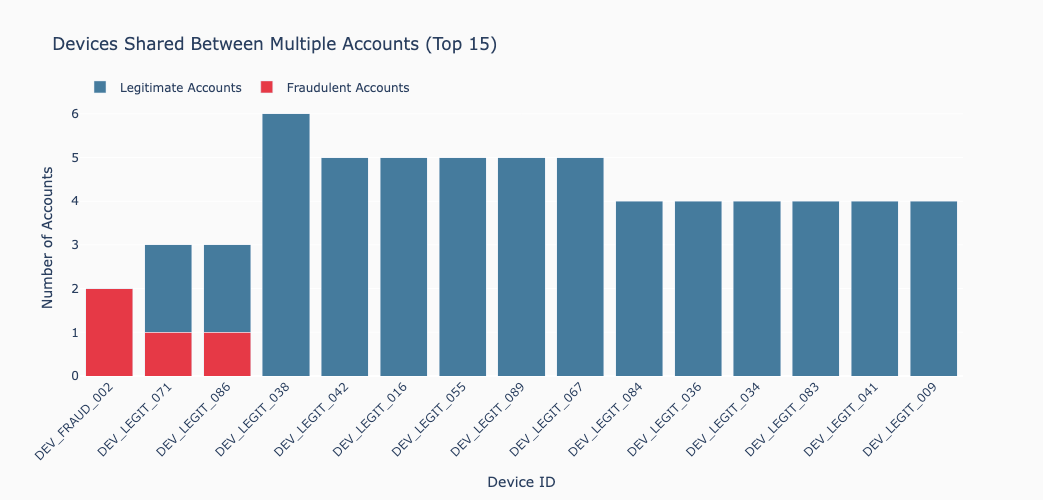

In [25]:
# Device sharing summary chart
with driver.session(database = NEO4J_DATABASE) as session:
    result = session.run("""
        MATCH (a:Account)-[:MADE]->(t:Transaction)-[:USED_DEVICE]->(d:Device)
        WITH d, collect(DISTINCT a) AS accounts
        WHERE size(accounts) > 1
        RETURN d.device_id AS device_id,
               size(accounts) AS num_accounts,
               size([a IN accounts WHERE a.is_fraud = true]) AS fraud_accounts
        ORDER BY fraud_accounts DESC, num_accounts DESC
        LIMIT 15
    """)
    device_records = result.data()

devices = [r["device_id"] for r in device_records]
total_accounts = [r["num_accounts"] for r in device_records]
fraud_counts = [r["fraud_accounts"] for r in device_records]
legit_counts = [r["num_accounts"] - r["fraud_accounts"] for r in device_records]

fig2 = go.Figure(
    data = [
        go.Bar(name = "Fraudulent Accounts", x = devices, y = fraud_counts, marker_color = "#E63946"),
        go.Bar(name = "Legitimate Accounts", x = devices, y = legit_counts, marker_color = "#457B9D"),
    ],
    layout = go.Layout(
        title = "Devices Shared Between Multiple Accounts (Top 15)",
        barmode = "stack",
        xaxis = dict(title = "Device ID", tickangle = -45),
        yaxis = dict(title = "Number of Accounts"),
        plot_bgcolor = "#FAFAFA",
        paper_bgcolor = "#FAFAFA",
        height = 500,
        legend = dict(orientation = "h", y = 1.1),
    )
)

fig2.show()

## Cleanup

In [26]:
driver.close()

print("Connection closed.")

Connection closed.
